In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

from Kakapo.photometry import forced_photometry
from Kakapo.difference_image import Difference_Imaging
from Kakapo.cleaning_curve import *

%matplotlib widget

In [ ]:
# def filter_detections(stars, corrlim = 0, difflim = 2, fwhmlim = 5, 
#                       maxlim = 0, snrlim = 4, roundness = 0.8, poiss_val = 2):
    
#     corr = stars[(stars.correlation > corrlim) & 
#                 (stars.psfdiff <  difflim) & 
#                 (stars.fwhm < fwhmlim) &  (stars.fwhm >= 1.0) & 
#                 (stars.max_value > maxlim) & 
#                 (stars.snr > snrlim) & (stars.snr < 10000) & 
#                 (abs(stars.roundness) <= roundness) & 
#                 (stars.poisson_thresh >= poiss_val)]
    
#     return corr

# def merge_close_clusters_fast(corr, dist_tolerance=0.6, f_dist=12):
#     if 'cluster' not in corr.columns or len(corr) == 0:
#         return corr

#     unique_clusters = np.unique(corr['cluster'])
#     n_clusters = len(unique_clusters)

#     cluster_idx_map = {cid: i for i, cid in enumerate(unique_clusters)}
#     idx_to_cluster = {i: cid for cid, i in cluster_idx_map.items()}

#     cluster_props = np.zeros((n_clusters, 5))  # x, y, fmin, fmax, cluster_id
#     for i, cid in enumerate(unique_clusters):
#         sub = corr[corr['cluster'] == cid]
#         cluster_props[i, 0] = sub['xcentroid'].mean()
#         cluster_props[i, 1] = sub['ycentroid'].mean()
#         cluster_props[i, 2] = sub['frame'].min()
#         cluster_props[i, 3] = sub['frame'].max()
#         cluster_props[i, 4] = cid

#     tree = cKDTree(cluster_props[:, :2])
#     pairs = tree.query_pairs(r=dist_tolerance)

#     rows, cols = [], []
#     for i, j in pairs:
#         fmin_i, fmax_i = cluster_props[i, 2], cluster_props[i, 3]
#         fmin_j, fmax_j = cluster_props[j, 2], cluster_props[j, 3]

#         frame_gap = max(0, min(abs(fmin_i - fmax_j), abs(fmin_j - fmax_i)))
#         if frame_gap <= f_dist:
#             rows.extend([i, j])
#             cols.extend([j, i])  # Make the graph undirected

#     graph = csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(n_clusters, n_clusters))
#     n_components, labels = connected_components(csgraph=graph, directed=False)

#     new_cluster_ids = {idx_to_cluster[i]: new_id for i, new_id in enumerate(labels)}
#     corr['cluster'] = corr['cluster'].map(new_cluster_ids)

#     return corr


# def _grouping(corr, f_dist = 12):
    
#     def custom_distance(p1, p2):
#         xy_dist = np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2) # Euclidean distance for xcentroid and ycentroid
#         frame_dist = np.abs(p1[2] - p2[2]) # Absolute difference for frame
        
#         if xy_dist <= 0.6 and frame_dist <= f_dist: # Combine both distances with their respective thresholds
#             return 0  # In the same cluster (distance 0 means they are close enough)
#         else:
#             return 5  # Distance larger than threshold, separate clusters

#     try:
#         data = corr[['xcentroid', 'ycentroid', 'frame']].values

#         db = DBSCAN(eps=1, min_samples=5, metric=custom_distance)  # 'metric' could be adjusted for your use case
#         corr['cluster'] = db.fit_predict(data)
        
#         corr = corr[corr['cluster'] != -1]
        
#     except:
#         return None
    
#     return corr

In [ ]:
# file = '/Users/zgl12/Modules/Kakapo/csv_files/c3/c3_t205922648.csv'
# df = pd.read_csv(file)

# print(len(df))

# df = filter_detections(df, corrlim = 0.01, difflim = 2, fwhmlim = 8, maxlim = 0, snrlim = 4, roundness = 0.95, poiss_val = 1)

# print(len(df))

In [ ]:
# epsf = np.genfromtxt('epsf_data.txt')

# epsf = epsf[2:-2,2:-2]

# print(epsf)

In [ ]:
# plt.figure()
# plt.scatter(df['xcentroid'].values, df['ycentroid'].values, c = df['frame'].values)
# plt.show()

# plt.figure()
# plt.scatter(df['correlation'].values, df['psfdiff'].values, c = df['frame'].values)
# plt.show()

In [ ]:
df = _grouping(df, f_dist = 12)
df = merge_close_clusters_fast(df, dist_tolerance=0.25, f_dist=12)

np.unique(df['cluster'].values)

In [ ]:
# df = filter_detections(df, corrlim = 0.2, difflim = 1, fwhmlim = 5, maxlim = 0, snrlim = 4, roundness = 0.8, poiss_val = 2)

# df

In [ ]:
# i =0 

# for cluster in np.unique(df['cluster'].values):
#     clust = df[df['cluster'] == cluster]
    
#     if len(clust) < 5:
#         pass
#     else:
#         print(cluster)
    
#     print(len(clust), np.nanmin(clust['frame'].values), np.nanmax(clust['frame'].values))
#     print(np.nanmean(clust['xcentroid'].values), np.nanmean(clust['ycentroid'].values), 
#           np.nanstd(clust['xcentroid'].values, ddof = 1), np.nanstd(clust['ycentroid'].values, ddof = 1))
    
#     if i == 1:
#         break
    
#     i += 1

In [3]:
diff = np.load('/Users/zgl12/Modules/Kakapo/Data/difference_arrays/c3/diff_c3_t205922648.npy')

flux_ap = forced_photometry(diff, 6.91, 7.18, None, bkg = False)
flux_ap_bkg = forced_photometry(diff, 6.91, 7.18, None, bkg = True)
# flux_psf = forced_photometry(diff, 6.91, 7.18, epsf, bkg = False, method = 'psf')
# flux_psf_bkg = forced_photometry(diff, 6.91, 7.18, epsf, bkg = True, method = 'psf')
# flux_wap = forced_photometry(diff, 6.91, 7.18, epsf, bkg = False, method = 'weighted')
# flux_wap_bkg = forced_photometry(diff, 6.91, 7.18, epsf, bkg = True, method = 'weighted')
# flux_b = forced_photometry(diff, 7.46, 6.21, None)
# flux_c = forced_photometry(diff, 2.17, 6.13, None)

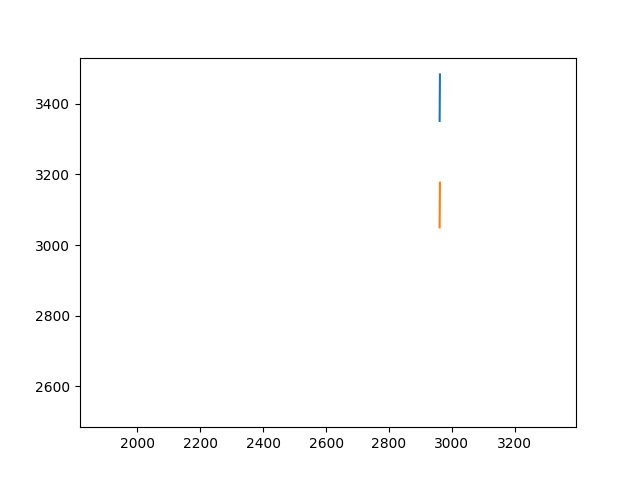

In [4]:
plt.figure()
plt.plot(flux_ap)
plt.plot(flux_ap_bkg)
# plt.plot(flux_psf)
# plt.plot(flux_psf_bkg)
# plt.plot(flux_wap)
# plt.plot(flux_wap_bkg)
# plt.plot(flux_c)
plt.show()
